# Mini Data Science Project: Genshin Impact Artifacts

**Our questions:**

1. Can we guess the final CV from the starting stats at level 0?
2. Can we spot a *keeper* early - an artifact that will finish in the top 10%?
3. Can we group finished artifacts into simple quality tiers (needs work / good / exceptional)?


## 1. Dataset selection

We use a simulated dataset of **1,000,000 Artifacts** from the game Genshin Impact. Each artifact was tracked at levels 0, 4, 8, 12, 16 and 20, so the table has **6,000,000 rows** (one row per snapshot).

### What each column means

| Column | Meaning |
|---|---|
| `artifact_id` | Which artifact this snapshot belongs to |
| `level` | Upgrade level (0, 4, 8, 12, 16, 20) |
| `slot`, `main_stat`, `sub_count` | Piece type and how many bonus stats it has |
| `cv` | Crit Value right now, in CV points (see formula below) |
| `has_crit_rate`, `has_crit_dmg` | Has those prized crit stats yet? (1 = yes, 0 = no) |
| `final_cv` | CV at level 20, in CV points (the target we want to predict) |

Crit Value formula:

$$ \text{CV} = 2 \times \text{Crit Rate\%} + \text{Crit Damage\%} $$


## 2. What is an Artifact?

Artifacts are gear pieces you level up from 0 to 20. Every 4 levels one random bonus stat gets stronger. Players want high Crit Value because it means more damage.

### Example: leveling a Flower

| Stat | Level 0 (start) | Level 20 (finished) |
|---|---|---|
| HP | +269 | +538 (1 upgrade) |
| ATK | +4.1% | +4.1% (no upgrade) |
| Crit Rate | +3.9% | +10.5% (2 upgrades) |
| Crit Damage | +7.8% | +21.8% (2 upgrades) |

How the CV adds up:

- Starting: $\text{CV}_0 = 2 \times 3.9 + 7.8 = 15.6$

- Final: $\text{CV}_{20} = 2 \times 10.5 + 21.8 = 42.8$


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

# Plain, readable plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.options.display.float_format = '{:,.2f}'.format


## 3. Data preparation

We load the data, check for gaps, look at the first rows and averages, then split off level 0 (for guessing the final number) and level 20 (for defining keepers and tiers). We split by `artifact_id` later so the same artifact never appears in both training and testing.

Cleaning checklist: missing values → `isnull().sum()` below (result: none, so no imputation needed); types → all numeric; ready splits → level 0 for regression/classification, level 20 for keeper line and clustering.



In [2]:
# Load the dataset
df = pd.read_csv('dataset/artifacts.csv')

from IPython.display import display

# Shape, missing values, first rows, averages
print(f"Rows: {len(df):,}, Artifacts: {df['artifact_id'].nunique():,}")
display(df.info())
display(df.isnull().sum())
display(df.head())
display(df.describe())


Rows: 6,000,000, Artifacts: 1,000,000
<class 'pandas.DataFrame'>
RangeIndex: 6000000 entries, 0 to 5999999
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   artifact_id    int64  
 1   level          int64  
 2   slot           int64  
 3   main_stat      int64  
 4   sub_count      int64  
 5   cv             float64
 6   has_crit_rate  int64  
 7   has_crit_dmg   int64  
 8   final_cv       float64
dtypes: float64(2), int64(7)
memory usage: 412.0 MB


None

artifact_id      0
level            0
slot             0
main_stat        0
sub_count        0
cv               0
has_crit_rate    0
has_crit_dmg     0
final_cv         0
dtype: int64

,artifact_id,level,slot,main_stat,sub_count,cv,has_crit_rate,has_crit_dmg,final_cv
0,0,0,0,7,3,6.99,0,1,26.42
1,0,4,0,7,4,13.99,1,1,26.42
2,0,8,0,7,4,13.99,1,1,26.42
3,0,12,0,7,4,20.98,1,1,26.42
4,0,16,0,7,4,26.42,1,1,26.42


,artifact_id,level,slot,main_stat,sub_count,cv,has_crit_rate,has_crit_dmg,final_cv
count,"6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00"
mean,"499,999.50",10.00,2.00,6.35,3.87,6.09,0.31,0.31,8.77
std,"288,675.16",6.83,1.41,3.13,0.34,7.20,0.46,0.46,9.68
min,0.00,0.00,0.00,0.00,3.00,0.00,0.00,0.00,0.00
25%,"249,999.75",4.00,1.00,5.00,4.00,0.00,0.00,0.00,0.00
50%,"499,999.50",10.00,2.00,6.00,4.00,5.44,0.00,0.00,6.22
75%,"749,999.25",16.00,3.00,7.00,4.00,7.78,1.00,1.00,14.76
max,"999,999.00",20.00,4.00,18.00,4.00,54.43,1.00,1.00,54.43


In [3]:
# How many snapshots per level?
print(df['level'].value_counts().sort_index().to_string())

# Split by level - level 0 for early guessing, level 20 for final quality
df_lvl0 = df[df['level'] == 0].copy()
df_lvl20 = df[df['level'] == 20].copy()
print(f"\nLevel 0 rows: {len(df_lvl0):,}")
print(f"Level 20 rows: {len(df_lvl20):,}")

# Define a keeper: top 10% of finished artifacts
keeper_threshold = df_lvl20['final_cv'].quantile(0.90)
df['keeper'] = df['final_cv'] >= keeper_threshold
df_lvl0['keeper'] = df_lvl0['final_cv'] >= keeper_threshold
df_lvl20['keeper'] = df_lvl20['final_cv'] >= keeper_threshold
print(f"\nKeeper means final CV >= {keeper_threshold:.1f} (top 10% at level 20)")
print(f"Keepers in total table: {df['keeper'].sum():,} out of {len(df):,}")
print(f"Anomalies (final CV > 40): {(df_lvl20['final_cv'] > 40).sum():,} out of {len(df_lvl20):,} finished ({(df_lvl20['final_cv'] > 40).mean()*100:.2f}%)")


level
0     1000000
4     1000000
8     1000000
12    1000000
16    1000000
20    1000000

Level 0 rows: 1,000,000
Level 20 rows: 1,000,000



Keeper means final CV >= 21.8 (top 10% at level 20)
Keepers in total table: 605,946 out of 6,000,000
Anomalies (final CV > 40): 3,395 out of 1,000,000 finished (0.34%)


## 4. First look at the data

Most finished artifacts are weak. Only a small slice on the right side of the chart counts as a keeper. On average CV grows steadily with each upgrade, but luck matters a lot.


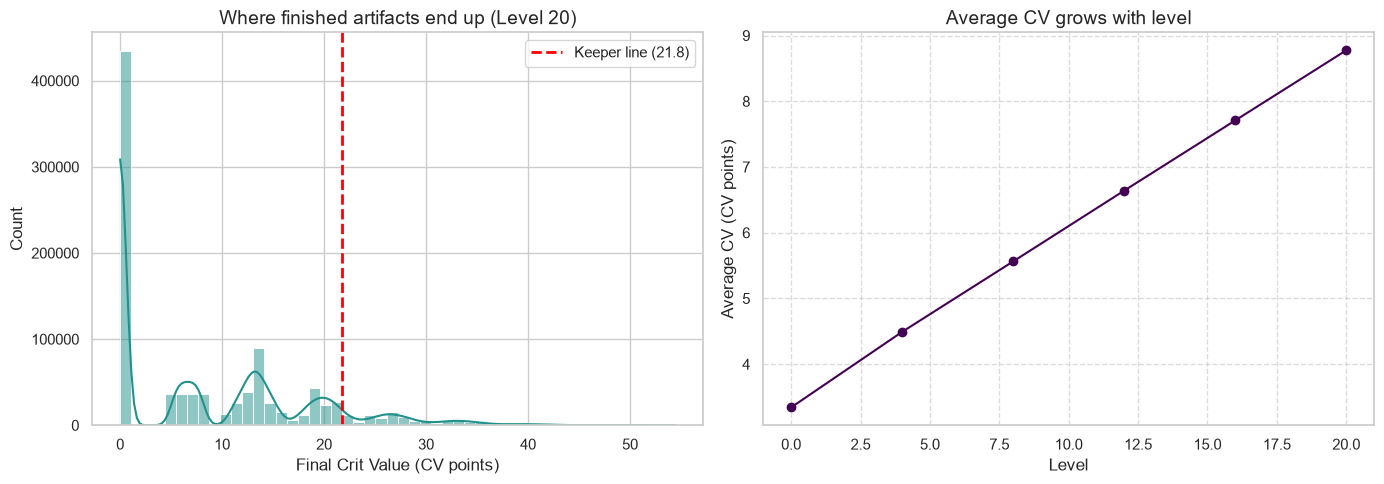

In [4]:
# Plot 1: where do finished artifacts end up? + keeper line
# Plot 2: average CV goes up with level
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_lvl20['final_cv'], bins=50, kde=True, color='#21918c', ax=axes[0])
axes[0].axvline(keeper_threshold, color='red', linestyle='--', linewidth=2,
                label=f'Keeper line ({keeper_threshold:.1f})')
axes[0].set_title('Where finished artifacts end up (Level 20)', fontsize=14)
axes[0].set_xlabel('Final Crit Value (CV points)')
axes[0].set_ylabel('Count')
axes[0].legend()

mean_cv_by_level = df.groupby('level')['cv'].mean()
axes[1].plot(mean_cv_by_level.index, mean_cv_by_level.values, marker='o', color='#440154')
axes[1].set_title('Average CV grows with level', fontsize=14)
axes[1].set_xlabel('Level')
axes[1].set_ylabel('Average CV (CV points)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('keeper_overview.png', dpi=150)
plt.show()


*Figure 1 — left: distribution of finished CV (n=1M at level 20); red dashed line = keeper cutoff at 21.8 CV (top 10%). Right: mean CV rises with level, but spread stays wide (luck matters).* 


## 5. Technique 1: Linear Regression

We start simple. Using only what we see at level 0 (`cv`, `sub_count`, and whether crit stats are present), we make one straight-line guess at the final score.

Think of it as:

starting stats $\rightarrow$ one guessed final number

How we judge the guesses:

- How far off are we on average, in CV points? (called $\text{RMSE}$)

- How much of the gap between good and bad artifacts do we capture? (called $R^2$, where 0 = nothing and 1 = perfect)

Note: starting CV already includes crit info, so the two yes/no crit flags add only a little on top. We leave out `slot` and `main_stat` here to keep things easy to explain.



In [5]:
# Technique 1: Linear Regression from level 0 stats
features_reg = ['sub_count', 'cv', 'has_crit_rate', 'has_crit_dmg']
X = df_lvl0[features_reg]
y = df_lvl0['final_cv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}  |  RMSE: {rmse:.2f}  |  R2: {r2:.2f}")
print(f"On average our guess is off by about {rmse:.1f} CV points.")
print("\nWhat the model learned (higher = pushes guess up):")
for name, coef in zip(features_reg, regressor.coef_):
    print(f"  {name}: {coef:.3f}")
print(f"  starting point: {regressor.intercept_:.2f}")


MSE: 41.16  |  RMSE: 6.42  |  R2: 0.56
On average our guess is off by about 6.4 CV points.

What the model learned (higher = pushes guess up):
  sub_count: -1.136
  cv: 0.999
  has_crit_rate: 5.761
  has_crit_dmg: 5.732
  starting point: 6.16


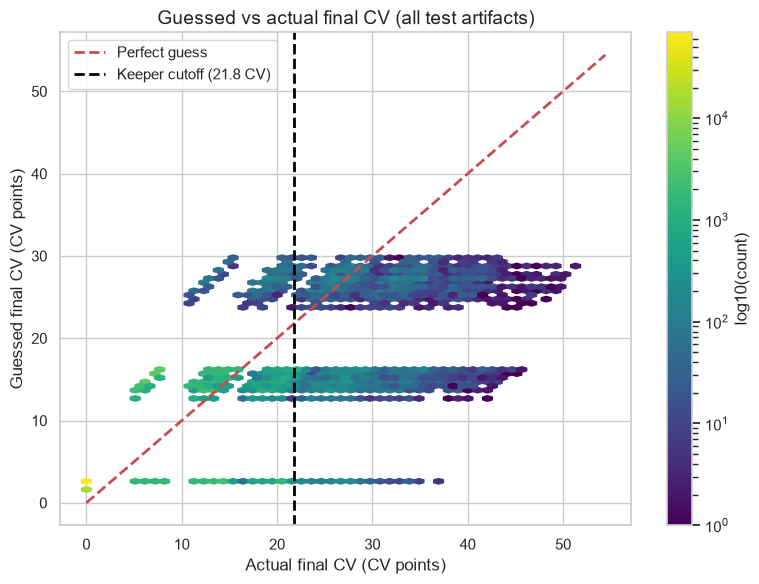

In [6]:
# Actual vs predicted: hexbin handles all test points, so no sampling needed
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_test, y_pred, gridsize=50, mincnt=1, bins='log', cmap='viridis')
plt.colorbar(hb, label='log10(count)')

mn, mx = float(y.min()), float(y.max())
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect guess')

# Keeper cutoff: the top 10% of final CV (black dashed: readable on bright bins)
cutoff = y.quantile(0.90)
plt.axvline(cutoff, color='black', ls='--', lw=2,
            label=f'Keeper cutoff ({cutoff:.1f} CV)')

plt.title('Guessed vs actual final CV (all test artifacts)', fontsize=14)
plt.xlabel('Actual final CV (CV points)')
plt.ylabel('Guessed final CV (CV points)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('actual_vs_guessed.png', dpi=150)
plt.show()


*Figure 2 — guessed vs actual final CV on all test artifacts (hexbin, log scale). Red dashed = perfect guess; black dashed = keeper cutoff at 21.8 CV.*

> **Takeaway:** $R^2$ of 0.56 means starting stats explain about half the story. The rest is upgrade luck, so no level-0 guess can be perfect (typical miss ~6.4 CV points).


## 6. Technique 2: Classification

Players do not need the exact final number. They need a yes/no answer: *is this worth leveling?*

We call the top 10% keepers. The cutoff sits around 21.8 CV.

Then at each level (0, 4, 8, 12, 16) we compare three classifiers:

- **Current CV only (baseline)** - just trust what you see now.

- **Classification: Logistic Regression** - one weight per stat, added up (simple weighted score).

- **Classification: Random Forest** - many small rules vote together (tree vote).

How we judge it:

- Ranking quality (called $AUC$): 0.5 = guessing, 1.0 = perfect.

- When it says keeper, how often is it right? And how many real keepers does it find?

We split by artifact ID so the same artifact is never in both training and testing. We sample 100k training rows per level so the notebook runs fast - results match full data within a point or two. Seed 42, 75/25 split by `artifact_id`.



In [7]:
# Technique 2: keeper classification per level
feature_cols = ['cv', 'sub_count', 'has_crit_rate', 'has_crit_dmg']
levels = [0, 4, 8, 12, 16]

# Split artifacts (not rows) so there is no leakage
unique_ids = df['artifact_id'].unique()
train_ids, test_ids = train_test_split(unique_ids, test_size=0.25, random_state=42)

results = []
print(f"{'Level':<6} | {'Base AUC':<9} | {'LogReg AUC':<11} | {'Forest AUC':<10} | {'Forest Prec':<11} | {'Forest Recal'}")
print("-" * 80)

for lvl in levels:
    df_lvl = df[df['level'] == lvl]
    train_df = df_lvl[df_lvl['artifact_id'].isin(train_ids)].sample(n=100000, random_state=42)
    test_df = df_lvl[df_lvl['artifact_id'].isin(test_ids)].sample(n=25000, random_state=42)
    X_train, y_train = train_df[feature_cols], train_df['keeper']
    X_test, y_test_lvl = test_df[feature_cols], test_df['keeper']

    # Baseline: current CV as the score
    baseline_auc = roc_auc_score(y_test_lvl, X_test['cv'])

    # Simple model
    lr = LogisticRegression(class_weight='balanced', max_iter=1000)
    lr.fit(X_train, y_train)
    lr_auc = roc_auc_score(y_test_lvl, lr.predict_proba(X_test)[:, 1])

    # Tree vote
    rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_probs = rf.predict_proba(X_test)[:, 1]
    rf_preds = rf.predict(X_test)
    rf_auc = roc_auc_score(y_test_lvl, rf_probs)
    rf_prec = precision_score(y_test_lvl, rf_preds, zero_division=0)
    rf_rec = recall_score(y_test_lvl, rf_preds, zero_division=0)

    results.append({'level': lvl, 'baseline': baseline_auc, 'logreg': lr_auc,
                    'forest': rf_auc, 'prec': rf_prec, 'rec': rf_rec})
    print(f"+{lvl:<5} | {baseline_auc:<9.4f} | {lr_auc:<11.4f} | {rf_auc:<10.4f} | {rf_prec:<11.4f} | {rf_rec:.4f}")

res_df = pd.DataFrame(results)
display(res_df)


Level  | Base AUC  | LogReg AUC  | Forest AUC | Forest Prec | Forest Recal
--------------------------------------------------------------------------------


+0     | 0.8410    | 0.8432      | 0.8445     | 0.7459      | 0.3599


+4     | 0.9138    | 0.9169      | 0.9168     | 0.7344      | 0.6186


+8     | 0.9422    | 0.9501      | 0.9502     | 0.7468      | 0.6246


+12    | 0.9660    | 0.9704      | 0.9707     | 0.8575      | 0.6111


+16    | 0.9843    | 0.9855      | 0.9872     | 0.8901      | 0.7416


,level,baseline,logreg,forest,prec,rec
0,0,0.84,0.84,0.84,0.75,0.36
1,4,0.91,0.92,0.92,0.73,0.62
2,8,0.94,0.95,0.95,0.75,0.62
3,12,0.97,0.97,0.97,0.86,0.61
4,16,0.98,0.99,0.99,0.89,0.74


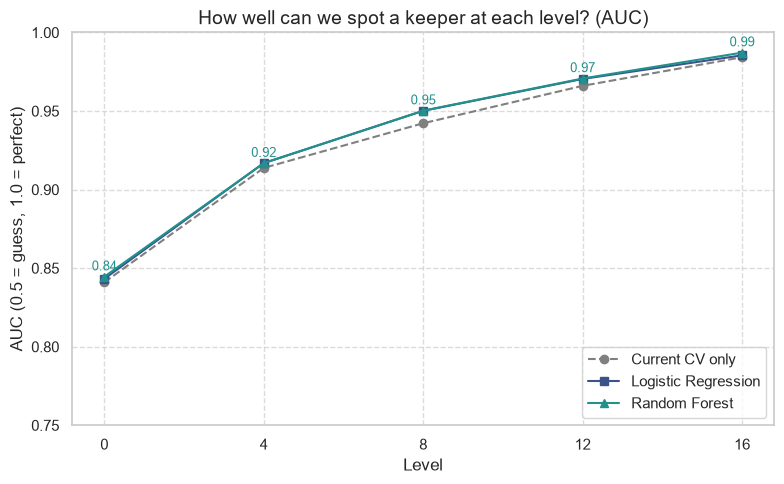

In [8]:
# AUC goes up with level: early guesses are decent, late calls are very safe
plt.figure(figsize=(8, 5))
plt.plot(res_df['level'], res_df['baseline'], marker='o', linestyle='--', color='gray', label='Current CV only')
plt.plot(res_df['level'], res_df['logreg'], marker='s', color='#3b528b', label='Logistic Regression')
plt.plot(res_df['level'], res_df['forest'], marker='^', color='#21918c', label='Random Forest')
for x, v in zip(res_df['level'], res_df['forest']):
    plt.text(x, v + 0.004, f'{v:.2f}', ha='center', fontsize=9, color='#21918c')
plt.title('How well can we spot a keeper at each level? (AUC)', fontsize=14)
plt.xlabel('Level')
plt.ylabel('AUC (0.5 = guess, 1.0 = perfect)')
plt.xticks(levels)
plt.ylim(0.75, 1.0)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('keeper_auc.png', dpi=150)
plt.show()


*Figure 3 — keeper-ranking quality (AUC) by level. Labels show Random Forest AUC: ~0.84 at level 0 rising to ~0.99 at level 16. Practical rule: be strict early, trust the call from level 12 on.*


## 7. Technique 3: Clustering (K-means)

We group finished artifacts by final CV into 3 tiers: needs-work, good, and exceptional.

We use CV only because `sub_count` at level 20 is almost always 4, so it does not help separate groups. Values are rescaled first so the grouping is fair, then centers are converted back to real CV.



In [9]:
# Technique 3: K-Means on finished CV (1-D, so groups are easy to explain)
X_final = df_lvl20[['cv']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_lvl20['tier'] = kmeans.fit_predict(X_scaled)

# Convert centers back to real CV numbers and sort low -> high
centers_cv = scaler.inverse_transform(kmeans.cluster_centers_).flatten()
order = np.argsort(centers_cv)
remap = {old: new for new, old in enumerate(order)}
df_lvl20['tier'] = df_lvl20['tier'].map(remap)
centers_sorted = np.sort(centers_cv)

print("Tier centers (real CV):")
for i, c in enumerate(centers_sorted):
    print(f"  Tier {i}: ~{c:.1f} CV")
print("\nCounts per tier:")
print(df_lvl20['tier'].value_counts().sort_index().to_string())
tier_names = {0: 'Needs work', 1: 'Good', 2: 'Exceptional'}
print("\nMeaning:", tier_names)


Tier centers (real CV):
  Tier 0: ~1.7 CV
  Tier 1: ~15.6 CV
  Tier 2: ~28.9 CV

Counts per tier:
tier
0    579575
1    324682
2     95743

Meaning: {0: 'Needs work', 1: 'Good', 2: 'Exceptional'}


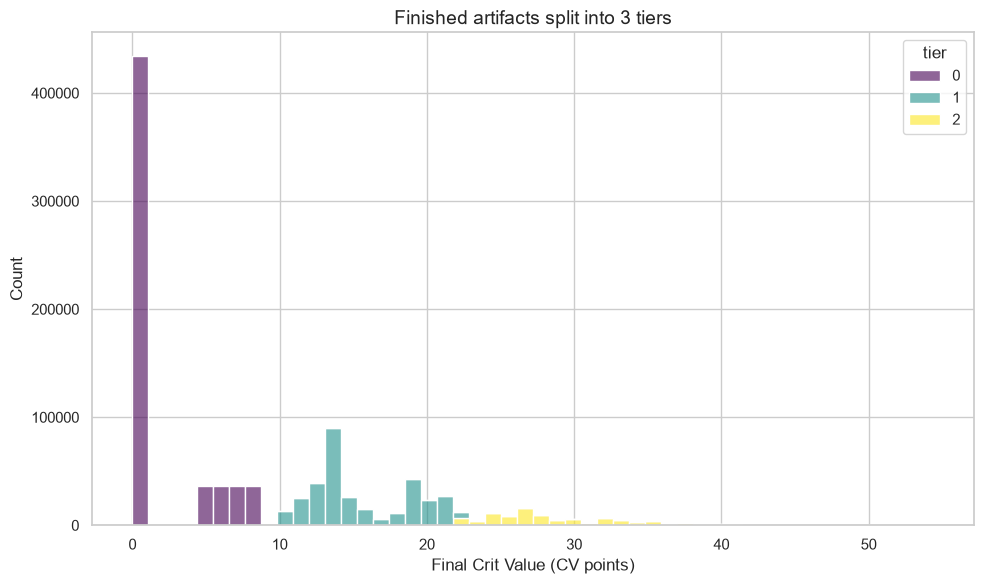

In [10]:
# Finished artifacts colored by tier
plt.figure(figsize=(10, 6))
sns.histplot(data=df_lvl20, x='cv', hue='tier', bins=50, palette='viridis', alpha=0.6, multiple='stack')
plt.title('Finished artifacts split into 3 tiers', fontsize=14)
plt.xlabel('Final Crit Value (CV points)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('tiers.png', dpi=150)
plt.show()


*Figure 4 — finished artifacts (n=1M) stacked by K-means tier: needs-work (~1.7 CV center, bulk on the left), good (~15.6 CV), exceptional (~28.9 CV, keeper zone on the right).* 


## 8. What we found

**TL;DR:** Only the top 10% are keepers (CV ≥ 21.8) · Level-0 guess misses by ~6.4 CV points (R² 0.56) · Keeper calls get safe from level 12 on (AUC 0.97+) · Finished pieces split into 3 tiers.

- **Most artifacts finish weak.** Average finished CV is about 8.8, median is about 6.2. The keeper line sits at 21.8 CV. Anything above 40 CV is very rare and very valuable.
- **Starting stats help but luck matters.** Guessing from level 0 is off by about 6.4 CV points on average (RMSE 6.42, R² 0.56) and captures about half the gap between good and bad pieces.
- **Keep-or-toss gets safer as you level.** Current CV alone already ranks well (AUC about 0.84 at level 0, about 0.99 at level 16 on a 0.5-to-1.0 scale). The tree vote (Random Forest) is a little better early on. Practical rule: be strict early, trust the call from level 12 on.
- **Three clear tiers.** Finished pieces split into needs-work (~1.7 CV center, bulk), good (~15.6 CV), and exceptional (~28.9 CV, keeper zone on the right).

### Limits and next steps
- This data is simulated to mimic game odds, not pulled from real accounts, so real drop rates may differ.
- We kept the models simple on purpose (`cv` + 3 helper columns). Adding `slot` and `main_stat` or trying per-level thresholds is an easy follow-up.
- For players: do not throw away everything early (level 0 calls still miss). Re-check at 8-12 before deciding.

*Reproducibility: seed 42 everywhere; 75/25 split by `artifact_id` (no leakage); classification sampled at 100k train / 25k test rows per level.*
